### Importación de datos



In [30]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
ur2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
ur3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
ur4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(ur2)
tienda3 = pd.read_csv(ur3)
tienda4 = pd.read_csv(ur4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [31]:
tienda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


In [32]:
tienda.describe()

,Precio,Costo de envío,Calificación,Cantidad de cuotas,lat,lon
count,2.359000e+03,2359.000000,2359.000000,2359.000000,2359.000000,2359.000000
mean,4.878679e+05,26018.609580,3.976685,2.943196,5.365283,-74.789417
std,6.146868e+05,32860.001783,1.415370,2.819897,2.287445,1.217827
min,7.600000e+03,0.000000,1.000000,1.000000,-4.215280,-77.281110
25%,5.575000e+04,3100.000000,3.000000,1.000000,4.609710,-75.563590
50%,2.353000e+05,12400.000000,5.000000,1.000000,4.609710,-74.199040
75%,6.781000e+05,36000.000000,5.000000,4.000000,6.251840,-74.081750
max,2.977000e+06,160800.000000,5.000000,24.000000,11.544440,-67.923900


#1. Análisis de facturación



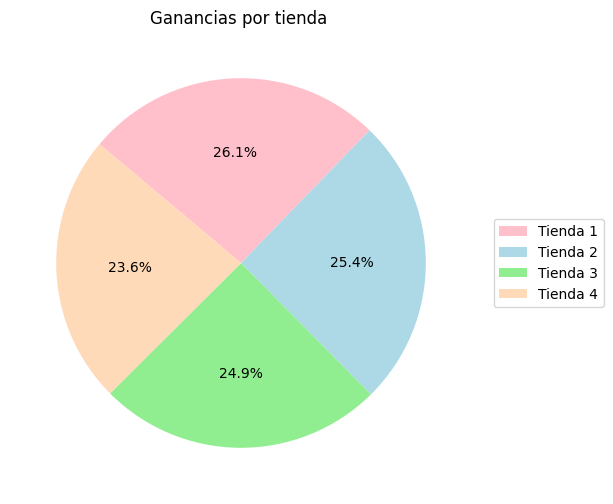

In [33]:
colors = ['#FFC0CB', '#ADD8E6', '#90EE90', '#FFDAB9']

ingresos_tienda = tienda['Precio'].sum()/1000000
ingresos_tienda2 = tienda2['Precio'].sum()/1000000
ingresos_tienda3 = tienda3['Precio'].sum()/1000000
ingresos_tienda4 = tienda4['Precio'].sum()/1000000
ingresos = (ingresos_tienda, ingresos_tienda2, ingresos_tienda3, ingresos_tienda4)


plt.figure(figsize=(8, 6))
plt.pie(ingresos, colors=colors, autopct='%1.1f%%', counterclock=False, startangle=140)
plt.title('Ganancias por tienda ')
plt.legend(['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'], loc='right', bbox_to_anchor=(1.3, 0.5))
plt.show()

# 2. Ventas por categoría

Mas vendidos

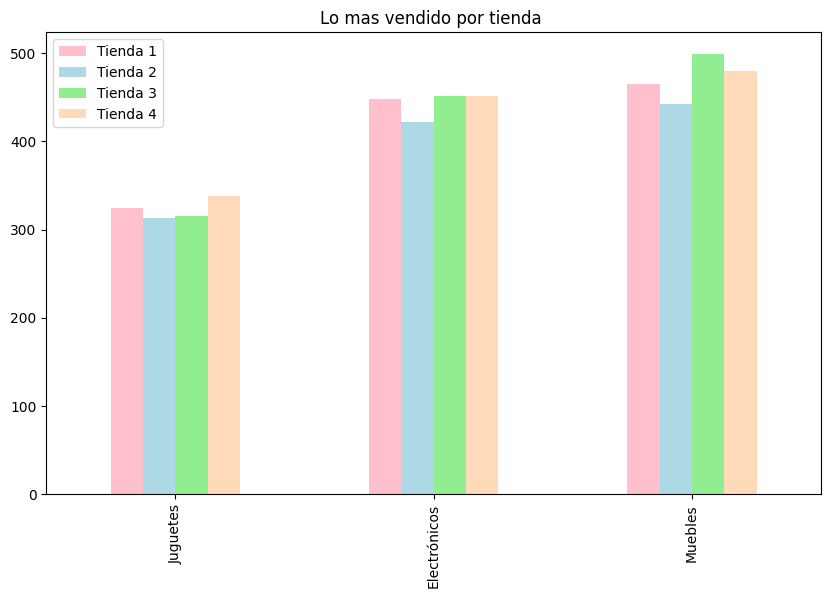

In [34]:
tienda1_mas_vendidos = tienda['Categoría del Producto'].value_counts().sort_values(ascending=False).to_dict()
tienda2_mas_vendidos = tienda2['Categoría del Producto'].value_counts().sort_values(ascending=False).to_dict()
tienda3_mas_vendidos = tienda3['Categoría del Producto'].value_counts().sort_values(ascending=False).to_dict()
tienda4_mas_vendidos = tienda4['Categoría del Producto'].value_counts().sort_values(ascending=False).to_dict()

mayores_ventas = pd.DataFrame({
    'Tienda 1': tienda1_mas_vendidos,
    'Tienda 2': tienda2_mas_vendidos,
    'Tienda 3': tienda3_mas_vendidos,
    'Tienda 4': tienda4_mas_vendidos
})

categorias_mas_vendidas = mayores_ventas.sum(axis=1).sort_values(ascending=False).index.tolist()[:3]
categorias_mas_vendidas.reverse() # Reverse the order of the top 3 categories
mayores_ventas.loc[categorias_mas_vendidas].plot.bar(figsize=(10,6), color=colors)
plt.title('Lo mas vendido por tienda ')
plt.show()

Menos vendidos

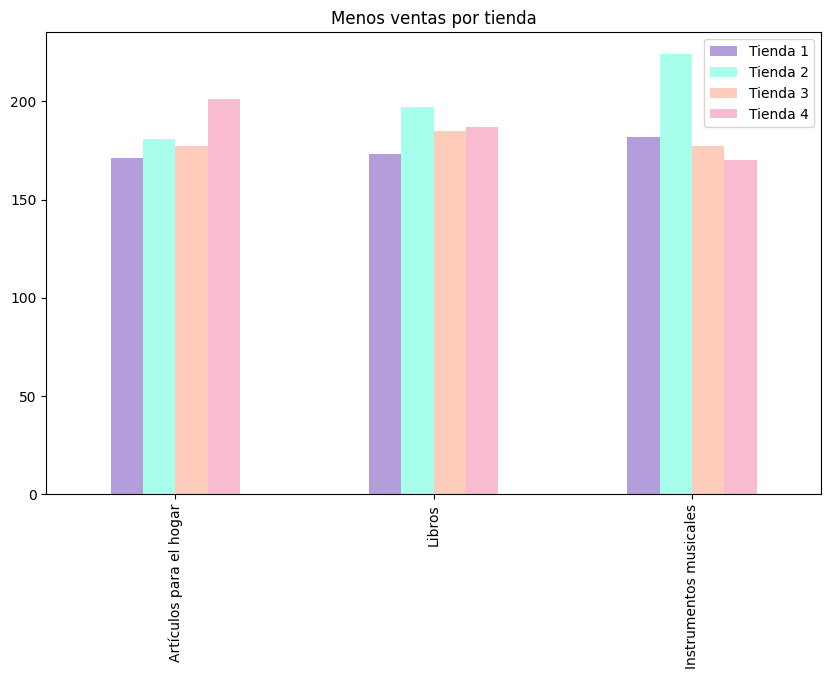

In [35]:
tienda1_menos_vendidos = tienda['Categoría del Producto'].value_counts().sort_values(ascending=True).to_dict()
tienda2_menos_vendidos = tienda2['Categoría del Producto'].value_counts().sort_values(ascending=True).to_dict()
tienda3_menos_vendidos = tienda3['Categoría del Producto'].value_counts().sort_values(ascending=True).to_dict()
tienda4_menos_vendidos = tienda4['Categoría del Producto'].value_counts().sort_values(ascending=True).to_dict()

menos_vendidos = pd.DataFrame({
    'Tienda 1': tienda1_menos_vendidos,
    'Tienda 2': tienda2_menos_vendidos,
    'Tienda 3': tienda3_menos_vendidos,
    'Tienda 4': tienda4_menos_vendidos
})

categorias_menos_vendidas = menos_vendidos.sum(axis=1).sort_values(ascending=True).index.tolist()[:3]


new_colors = ['#B39DDB', '#A7FFEB', '#FFCCBC', '#F8BBD0']
menos_vendidos.loc[categorias_menos_vendidas].plot.bar(figsize=(10,6), color=new_colors)
plt.title('Menos ventas por tienda')
plt.show()

# 3. Calificación promedio de la tienda


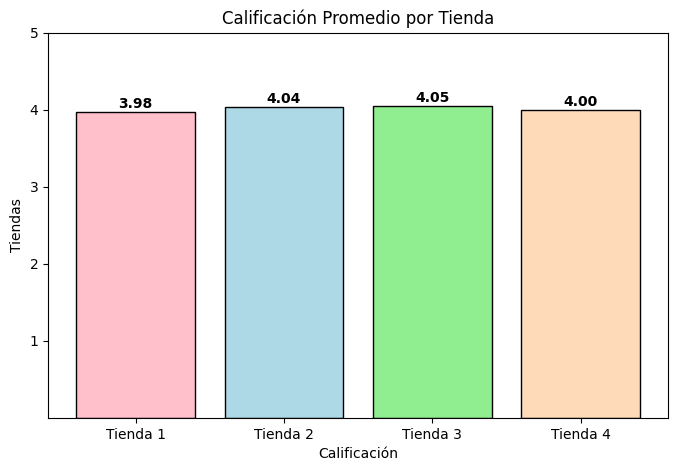

In [36]:
calificacion_tienda = tienda['Calificación'].mean()
calificacion_tienda2 = tienda2['Calificación'].mean()
calificacion_tienda3 = tienda3['Calificación'].mean()
calificacion_tienda4 = tienda4['Calificación'].mean()
calificacion = [calificacion_tienda, calificacion_tienda2, calificacion_tienda3, calificacion_tienda4]

plt.figure(figsize=(8,5))
plt.bar(["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"], calificacion, color=colors, edgecolor='black')

plt.xlabel('Calificación')
plt.ylabel('Tiendas')
plt.title('Calificación Promedio por Tienda')
plt.yticks([1, 2, 3, 4, 5])

for i, v in enumerate(calificacion):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center', fontweight='bold')

# 4. Productos más y menos vendidos

In [37]:
def obtener_top_extremos(df, n=3):
    counts = df['Producto'].value_counts()
    top_n = counts.head(n).index.tolist()
    top_cantidades = counts.head(n).values.tolist()
    bottom_n = counts.tail(n).index.tolist()
    bottom_cantidades = counts.tail(n).values.tolist()
    return top_n, top_cantidades, bottom_n, bottom_cantidades

tiendas_data = [tienda, tienda2, tienda3, tienda4]
resultados_expandidos = []

for i, df in enumerate(tiendas_data, 1):
    top_p, top_c, bot_p, bot_c = obtener_top_extremos(df)
    resultados_expandidos.append({
        'Tienda': f'Tienda {i}',
        'Mayores 3 Productos': ', '.join(top_p),
        'Cantidades (Max)': top_c,
        'Menores 3 Productos': ', '.join(bot_p),
        'Cantidades (Min)': bot_c
    })

df_productos_expandidos = pd.DataFrame(resultados_expandidos)
display(df_productos_expandidos)

,Tienda,Mayores 3 Productos,Cantidades (Max),Menores 3 Productos,Cantidades (Min)
0,Tienda 1,"Microondas, TV LED UHD 4K, Armario","[60, 60, 60]","Olla de presión, Auriculares con micrófono, Ce...","[35, 33, 33]"
1,Tienda 2,"Iniciando en programación, Microondas, Batería","[65, 62, 61]","Mesa de comedor, Impresora, Juego de mesa","[34, 34, 32]"
2,Tienda 3,"Kit de bancas, Mesa de comedor, Cama king","[57, 56, 56]","Mochila, Microondas, Bloques de construcción","[36, 36, 35]"
3,Tienda 4,"Cama box, Cubertería, Dashboards con Power BI","[62, 59, 56]","Guitarra acústica, Armario, Guitarra eléctrica","[37, 34, 33]"


# 5. Envío promedio por tienda

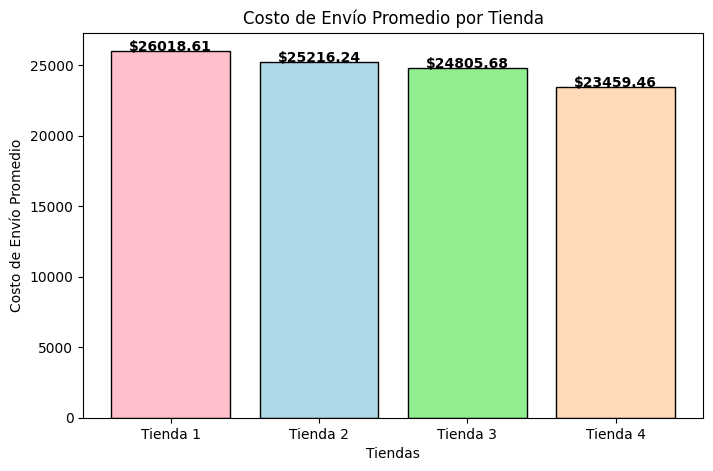

In [38]:
tienda1_promedio_envio = tienda['Costo de envío'].mean()
tienda2_promedio_envio = tienda2['Costo de envío'].mean()
tienda3_promedio_envio = tienda3['Costo de envío'].mean()
tienda4_promedio_envio = tienda4['Costo de envío'].mean()
promedio_envio = [tienda1_promedio_envio, tienda2_promedio_envio, tienda3_promedio_envio, tienda4_promedio_envio]
plt.figure(figsize=(8,5))
plt.bar(["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"], promedio_envio, color=colors, edgecolor='black')
plt.xlabel('Tiendas')
plt.ylabel('Costo de Envío Promedio')
plt.title('Costo de Envío Promedio por Tienda')
for i, v in enumerate(promedio_envio):
    plt.text(i, v + 0.5, f"${v:.2f}", ha='center', fontweight='bold')

##INFORME FINAL DE DECISION

# Informe Final: ¿Cuál es la mejor tienda para el Sr. Juan?

### Introducción
El objetivo de este análisis es ayudar al Sr. Juan a decidir en qué tienda le conviene más enfocarse. Revisamos las ventas, lo que opinan los clientes, qué productos salen más y cuánto cuesta enviar los pedidos en las cuatro tiendas disponibles.

### Análisis de los datos

1.  **Ganancias y Ventas:**
    *   La **Tienda 1** es la que más dinero genera (26.1% del total), seguida muy de cerca por la Tienda 2.
    *   En todas las tiendas, los productos que más se venden son los **Muebles** y la **Electrónica**, mientras que las cosas de hogar e instrumentos musicales no salen tanto.

2.  **Opinión de los Clientes:**
    *   Las calificaciones son parecidas, pero la **Tienda 3** tiene la mejor puntuación promedio (4.05), lo que significa que sus clientes están un poco más satisfechos.

3.  **Costos de Envío:**
    *   Aquí hay una diferencia importante: la **Tienda 4** tiene el envío más barato ($23,459 en promedio), mientras que la Tienda 1 es la más cara en este aspecto.

### Conclusión y Recomendación

Después de revisar todo, mi recomendación para el Sr. Juan es la **Tienda 1**.

**¿Por qué?**
*   Es la que más vende y la que más dinero trae a la caja.
*   Aunque el envío es un poco más caro, el volumen de ventas compensa este gasto.
*   Tiene una buena base de clientes comprando productos de alto valor como tecnología y muebles.

Como segunda opción, la **Tienda 3** es excelente si busca clientes más felices y un equilibrio entre buenas ventas y costos de envío controlados.